<a href="https://colab.research.google.com/github/Sanpie34/Samsung-Sales-Data-Analysis/blob/Yu-chan/Samsung_Sales_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import and Load

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Exploratory Data Analysis

## Explore Data

In [ ]:
df = pd.read_csv("/content/samsung_global_sales_dataset.csv")
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


In [ ]:
df.isnull().sum()

,0
sale_id,0
sale_date,0
year,0
quarter,0
month,0
country,0
region,0
city,0
product_name,0
category,0


In [ ]:
df.dropna(inplace = True)

In [ ]:
df.nunique()

,0
sale_id,4474
sale_date,1392
year,4
quarter,4
month,12
country,52
region,8
city,554
product_name,29
category,4


In [ ]:
unique_column = [col for col in df.columns if df[col].nunique() <= 12]

for col in unique_column:
  print(col)
  print(df[col].unique())
  print()

year
[2021 2022 2023 2024]

quarter
['Q2' 'Q3' 'Q1' 'Q4']

month
['May' 'September' 'February' 'July' 'December' 'April' 'June' 'January'
 'October' 'August' 'November' 'March']

region
['South America' 'Oceania' 'Europe' 'Asia' 'North America' 'Africa'
 'Europe/Asia' 'Middle East']

category
['Galaxy A' 'Galaxy Z' 'Galaxy S' 'Galaxy M']

storage
['128 GB' '256 GB' '64 GB' '512 GB' '1 TB']

is_5g
['Yes' 'No']

discount_pct
[12  0 15  7 10 20  2  3  5]

units_sold
[ 6  2  3  1  4  5  9  8 10  7]

sales_channel
['Corporate / B2B' 'Authorized Reseller' 'Third-Party Retailer'
 'E-commerce Platform' 'Samsung Store' 'Online (Samsung.com)'
 'Carrier Store']

payment_method
['Gift Card' 'Net Banking' 'BNPL (Buy Now Pay Later)' 'EMI / Installment'
 'Credit Card' 'Samsung Pay' 'Cash' 'Debit Card']

customer_segment
['Individual' 'Business' 'Government' 'Education' 'Enterprise']

customer_age_group
['25–34' '55+' '18–24' '35–44' '45–54']

previous_device_os
['New User' 'Android (Other)' 'Feature 

In [ ]:
df["customer_age_group"] = df["customer_age_group"].str.replace("–", "-")

In [ ]:
df["country"].value_counts()

,count
country,
Malaysia,106
Greece,105
Italy,102
Czech Republic,101
France,99
Egypt,98
Thailand,96
Australia,94
Austria,94


In [ ]:
df.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color', 'is_5g',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')

In [ ]:
df.shape

(4474, 28)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4474 entries, 2 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 4474 non-null   object 
 1   sale_date               4474 non-null   object 
 2   year                    4474 non-null   int64  
 3   quarter                 4474 non-null   object 
 4   month                   4474 non-null   object 
 5   country                 4474 non-null   object 
 6   region                  4474 non-null   object 
 7   city                    4474 non-null   object 
 8   product_name            4474 non-null   object 
 9   category                4474 non-null   object 
 10  storage                 4474 non-null   object 
 11  color                   4474 non-null   object 
 12  is_5g                   4474 non-null   object 
 13  unit_price_usd          4474 non-null   float64
 14  discount_pct            4474 non-null   int6

In [ ]:
df.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,4474.000000,4474.000000,4474.000000,4474.000000,4474.000000,4474.000000,4474.000000,4.474000e+03,4474.000000
mean,2022.518999,666.779303,5.723514,2.398972,628.202716,1498.695338,941.287211,1.399948e+06,3.741149
std,1.110373,462.568978,6.395158,1.919393,438.485983,1773.905266,3783.599528,8.653096e+06,0.720697
min,2021.000000,90.110000,0.000000,1.000000,72.800000,72.800000,0.790000,7.340000e+01,2.500000
25%,2022.000000,249.957500,0.000000,1.000000,238.392500,409.502500,1.340000,1.563065e+03,3.100000
50%,2023.000000,615.890000,3.000000,2.000000,568.595000,907.540000,10.550000,9.829680e+03,3.700000
75%,2024.000000,966.922500,10.000000,3.000000,920.542500,1845.800000,91.500000,1.011609e+05,4.400000
max,2024.000000,1960.410000,20.000000,10.000000,1958.360000,15818.760000,24500.000000,1.787162e+08,5.000000


## Analysis

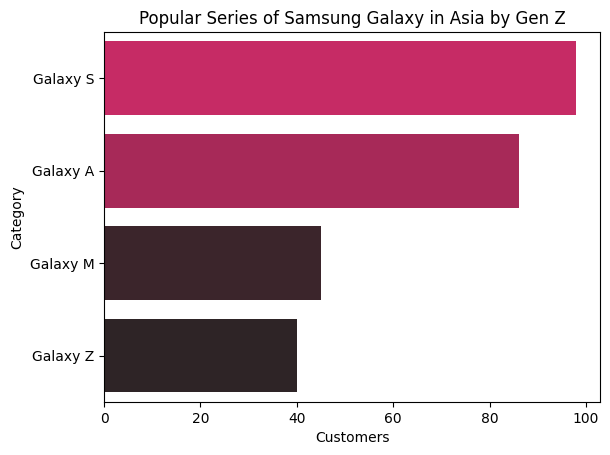

In [ ]:
df_asia = df[(df["region"] == "Asia") & (df["customer_age_group"] == "18-24")]

df_product = df_asia["category"].value_counts().to_frame()
sns.barplot(data = df_product, x = "count", y = "category", hue = "count", palette = "dark:#E0115F", legend = False)
plt.title("Popular Series of Samsung Galaxy in Asia by Gen Z")
plt.xlabel("Customers")
plt.ylabel("Category")
plt.show()

Insights
- The Samsung Galaxy S series is the most popular Samsung lineup among Gen Z in Asia, indicating that this segment prefers the Galaxy S series over other Samsung series in the region.

- The Samsung Galaxy Z series is the least preferred among Gen Z in Asia, suggesting that certain limitations or drawbacks may make the series less appealing to buyers.

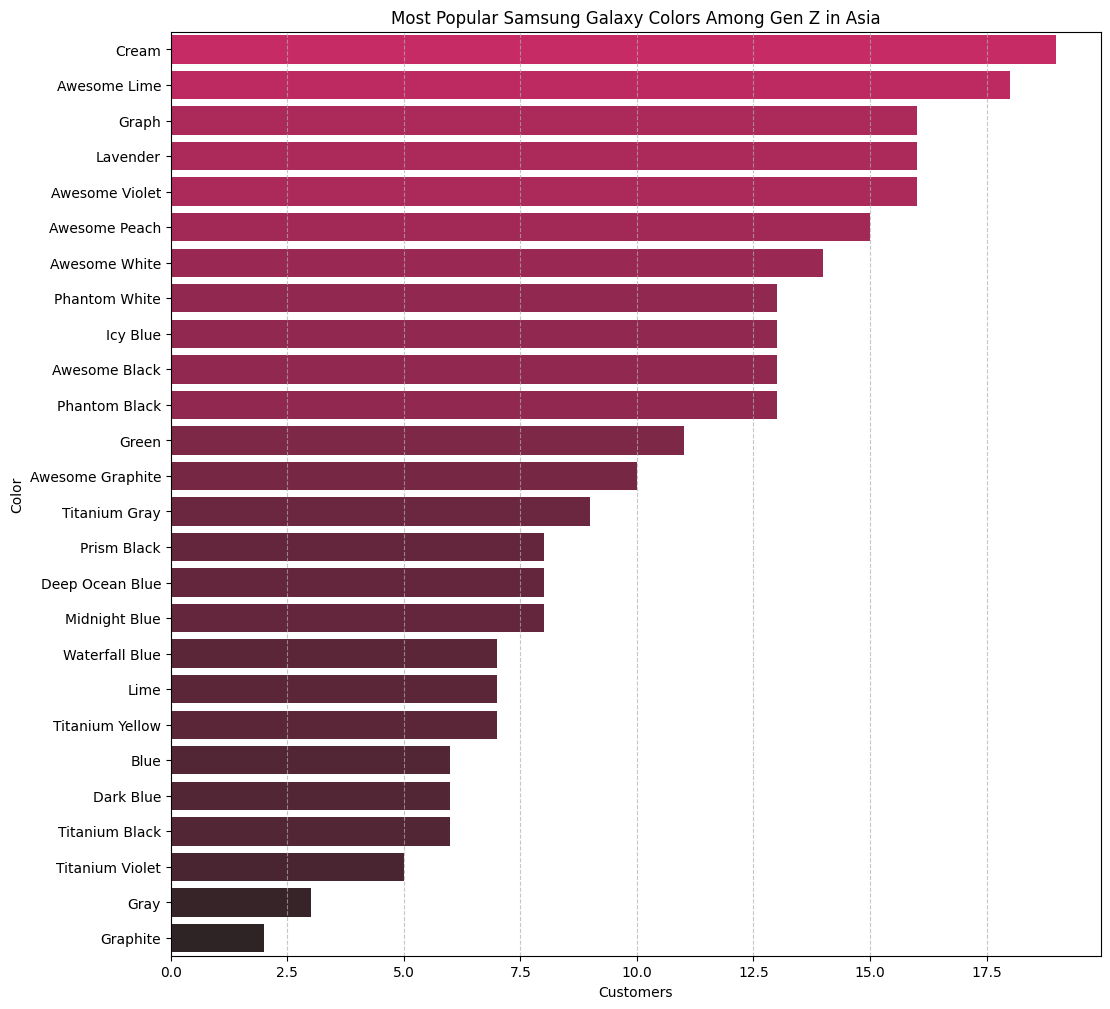

In [ ]:
df_color = df_asia["color"].value_counts().to_frame()
plt.figure(figsize = (12, 12))
sns.barplot(data = df_color, x = "count", y = "color", hue = "count", palette = "dark:#E0115F", legend = False)
plt.title("Most Popular Samsung Galaxy Colors Among Gen Z in Asia")
plt.xlabel("Customers")
plt.ylabel("Color")
plt.grid(axis = "x", linestyle = "--", alpha = 0.7)
plt.show()

Insights
- Cream, Awesome Lime, Graph, and Lavender are the most popular colors chosen by Gen Z in Asia, suggesting that the company should prioritize offering these colors in future products.

- Awesome-type colors show high popularity among Gen Z in Asia, indicating that these designs align well with their aesthetic preferences.

- Gray and Graphite are the least preferred colors among Gen Z in Asia, suggesting that these colors are less attractive for this segment when choosing a smartphone.

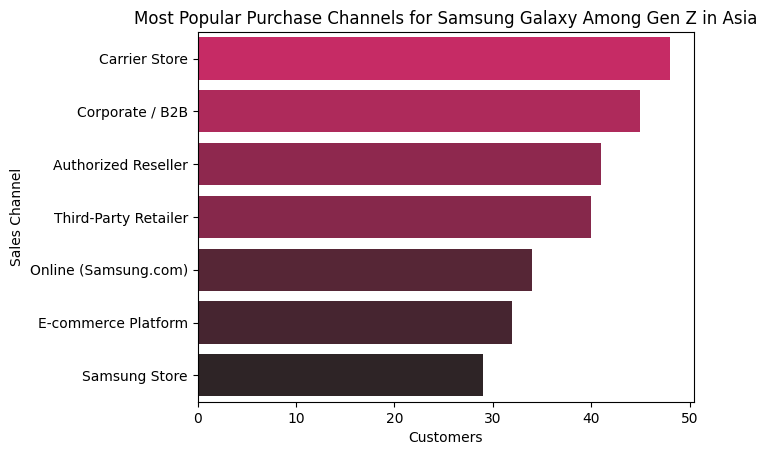

In [ ]:
df_buy_place = df_asia["sales_channel"].value_counts().to_frame()
sns.barplot(data = df_buy_place, x = "count", y = "sales_channel", hue = "count", palette = "dark:#E0115F", legend = False)
plt.title("Most Popular Purchase Channels for Samsung Galaxy Among Gen Z in Asia")
plt.xlabel("Customers")
plt.ylabel("Sales Channel")
plt.show()

Insights
- The plot indicates that Gen Z in Asia predominantly purchase smartphones through offline stores, as offline channels show higher values compared to online channels.

- Online purchasing channels show lower preference, which may indicate lingering concerns regarding product authenticity, safety, or purchasing reliability.

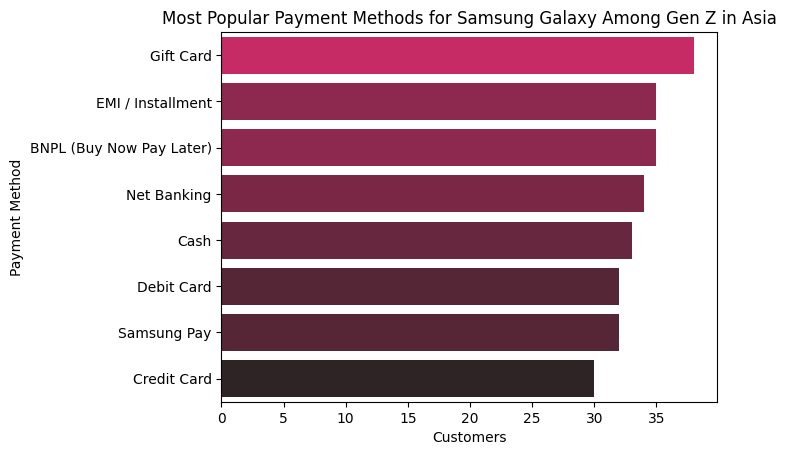

In [ ]:
df_payment = df_asia["payment_method"].value_counts().to_frame()
sns.barplot(data = df_payment, x = "count", y = "payment_method", hue = "count", palette = "dark:#E0115F", legend = False)
plt.title("Most Popular Payment Methods for Samsung Galaxy Among Gen Z in Asia")
plt.xlabel("Customers")
plt.ylabel("Payment Method")
plt.show()

Insights
- Gift cards dominate as the most used payment method, highlighting strong preference for convenience-driven and controlled spending options.

- EMI and BNPL show solid adoption, indicating demand for flexible financing among Gen Z.

- Credit cards lag behind other methods, suggesting lower relevance or adoption among younger consumers in Asia.

In [ ]:

df_preference = df_asia.groupby(["is_5g", "category", "storage"])[["unit_price_usd", "revenue_usd", "units_sold"]].agg(["count", "mean", "median", "sum"])
df_preference.reset_index()


is_5g  category storage unit_price_usd                                   \
                                    count         mean    median       sum   
0     No  Galaxy A  128 GB             12   158.979167   146.365   1907.75   
1     No  Galaxy A  256 GB             11   178.260909   163.750   1960.87   
2     No  Galaxy A   64 GB             16   175.281250   166.625   2804.50   
3     No  Galaxy M  128 GB              7   100.851429    99.660    705.96   
4     No  Galaxy M  256 GB              8   101.761250   102.750    814.09   
5     No  Galaxy M   64 GB              1   102.370000   102.370    102.37   
6     No  Galaxy S  256 GB              1   472.580000   472.580    472.58   
7    Yes  Galaxy A  128 GB             18   370.561111   395.020   6670.10   
8    Yes  Galaxy A  256 GB             17   336.936471   395.290   5727.92   
9    Yes  Galaxy A   64 GB             12   335.180000   356.895   4022.16   
10   Yes  Galaxy M  128 GB             10   283.893000   306.580   2838.93   
11   Yes  Galaxy M  256 GB             11   240.110000   232.230   2641.21   
12   Yes  Galaxy M   64 GB              8   255.251250   255.560   2042.01   
13   Yes  Galaxy S    1 TB             27   929.717778  1026.600  25102.38   
14   Yes  Galaxy S  128 GB             24   914.146667   843.070  21939.52   
15   Yes  Galaxy S  256 GB             17   965.564706   956.000  16414.60   
16   Yes  Galaxy S  512 GB             29   951.669655   966.980  27598.42   
17   Yes  Galaxy Z    1 TB             15  1245.126667  1029.820  18676.90   
18   Yes  Galaxy Z  256 GB             14  1231.371429  1078.540  17239.20   
19   Yes  Galaxy Z  512 GB             11  1047.974545   885.310  11527.72   

   revenue_usd                                  units_sold                   \
         count         mean    median       sum      count      mean median   
0           12   401.611667   345.065   4819.34         12  2.750000    2.5   
1           11   493.880909   327.500   5432.69         11  3.090909    2.0   
2           16   388.115000   228.795   6209.84         16  2.437500    1.5   
3            7   286.837143   287.070   2007.86          7  3.000000    3.0   
4            8   345.088750   195.210   2760.71          8  3.500000    2.0   
5            1   102.370000   102.370    102.37          1  1.000000    1.0   
6            1  3955.500000  3955.500   3955.50          1  9.000000    9.0   
7           18   753.730556   697.510  13567.15         18  2.222222    2.0   
8           17  1024.033529   696.840  17408.57         17  3.000000    2.0   
9           12  1010.603333   678.170  12127.24         12  3.166667    2.0   
10          10   486.277000   541.670   4862.77         10  1.800000    2.0   
11          11   550.874545   472.280   6059.62         11  2.727273    2.0   
12           8   629.708750   330.090   5037.67          8  2.750000    1.5   
13          27  1832.975926  1274.270  49490.35         27  1.962963    1.0   
14          24  2014.818333  1941.640  48355.64         24  2.333333    2.0   
15          17  2111.250000  1394.840  35891.25         17  2.235294    2.0   
16          29  2101.800345  1389.540  60952.21         29  2.344828    2.0   
17          15  2523.232000  1393.110  37848.48         15  2.000000    1.0   
18          14  1872.015000  1233.930  26208.21         14  1.428571    1.0   
19          11  2824.210909  1932.240  31066.32         11  2.545455    3.0   

        
   sum  
0   33  
1   34  
2   39  
3   21  
4   28  
5    1  
6    9  
7   40  
8   51  
9   38  
10  18  
11  30  
12  22  
13  53  
14  56  
15  38  
16  68  
17  30  
18  20  
19  28

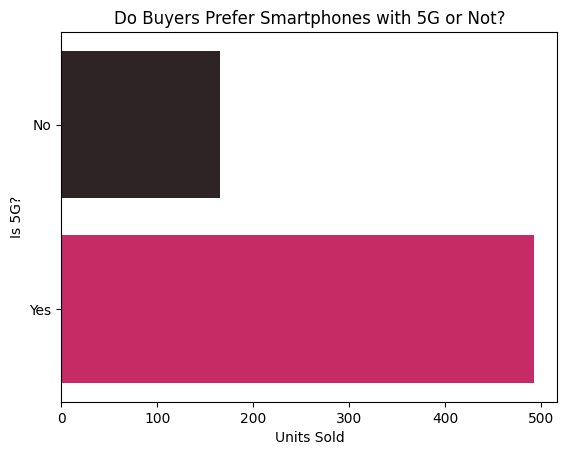

In [ ]:
df_preference_5g = df_preference["units_sold"].groupby("is_5g")["sum"].sum().to_frame()
sns.barplot(data = df_preference_5g, x = "sum", y = "is_5g", hue = "sum", palette = "dark:#E0115F", legend = False)
plt.title("Do Buyers Prefer Smartphones with 5G or Not?")
plt.xlabel("Units Sold")
plt.ylabel("Is 5G?")
plt.show()

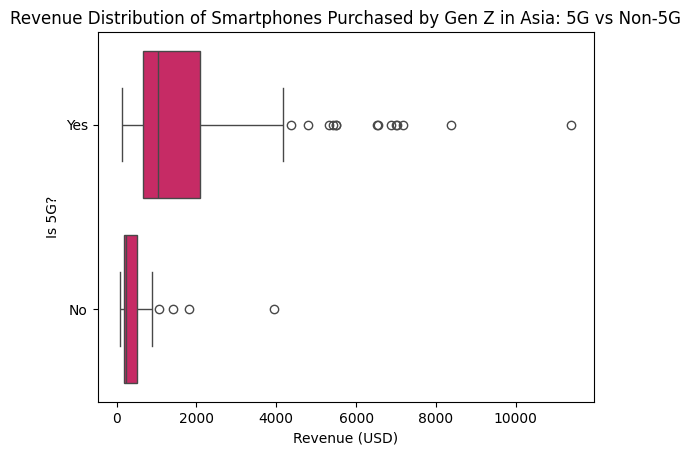

In [ ]:
sns.boxplot(data = df_asia, x = "revenue_usd", y = "is_5g", color = "#E0115F")
plt.title("Revenue Distribution of Smartphones Purchased by Gen Z in Asia: 5G vs Non-5G")
plt.xlabel("Revenue (USD)")
plt.ylabel("Is 5G?")
plt.show()

Insights
- Gen Z in Asia tend to prefer smartphones equipped with 5G features, suggesting that this generation is more tech-savvy and forward-looking in adopting newer technologies.

- 5G smartphones show a wider and higher revenue distribution compared to non-5G devices, with several high-value outliers, indicating that 5G models tend to generate greater revenue.

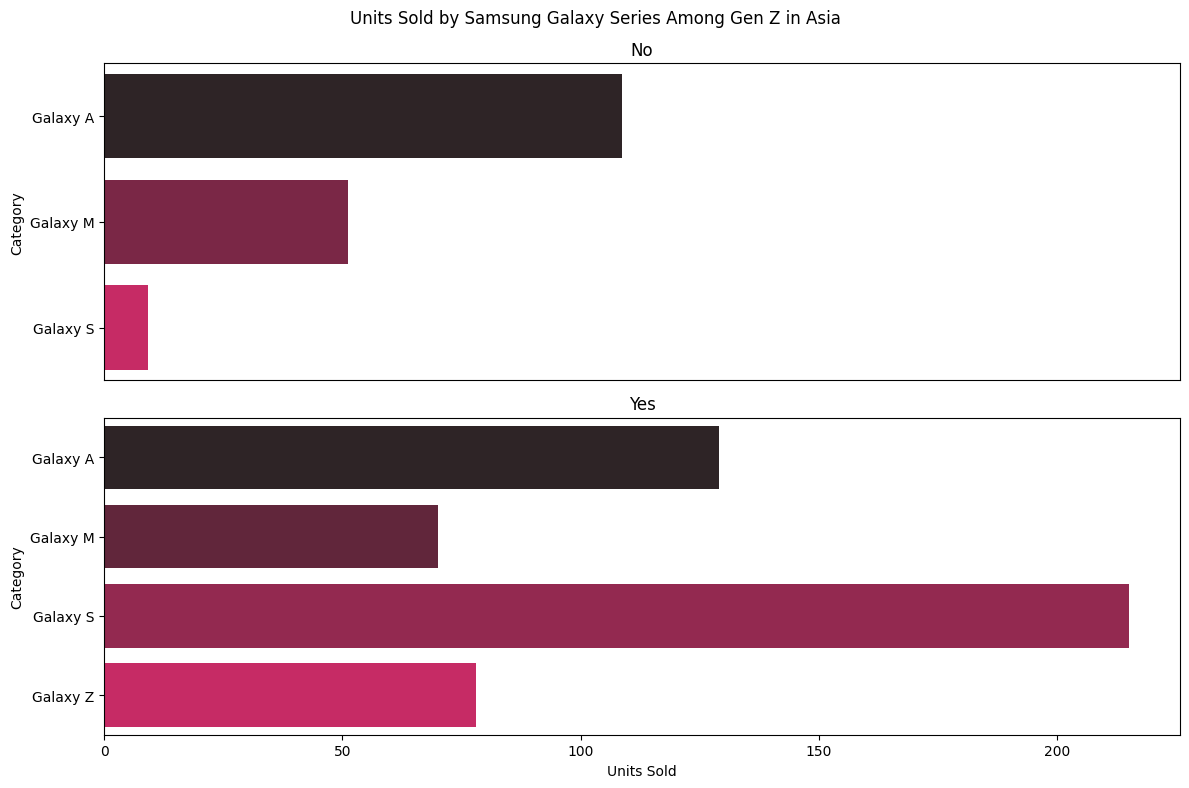

In [ ]:
df_5g = df_asia.groupby(["is_5g", "category"])[["unit_price_usd", "revenue_usd", "units_sold"]].agg(["count", "mean", "median", "sum"])
df_5g = df_5g["units_sold"].reset_index()
color = ["red", "blue", "green", "yellow"]

fig, ax = plt.subplots(2, 1, figsize = (12, 8))
plt.suptitle("Units Sold by Samsung Galaxy Series Among Gen Z in Asia")
for i, is_5g in enumerate(df_5g["is_5g"].unique()):
  df_plot_5g = df_5g[df_5g["is_5g"] == is_5g]
  sns.barplot(data = df_plot_5g, x = "sum", y = "category", ax = ax[i], hue = "category", palette = "dark:#E0115F", legend = False)
  ax[i].set_title(f"{is_5g}")
  ax[i].set_ylabel("Category")
  ax[i].set_xlim(0, max(df_5g["sum"]) + 0.05*max(df_plot_5g["sum"]))
  if i < len(df_5g["is_5g"].unique()) - 1:
    ax[i].xaxis.set_visible(False)
  else:
    ax[i].set_xlabel("Units Sold")

fig.tight_layout()
plt.show()

Insights
- For non-5G products, the Samsung Galaxy A series records the highest units sold compared to the M and S series. This may indicate that factors such as useful features and relatively lower prices make the Galaxy A series more attractive to Gen Z consumers in Asia.

- For 5G products, the Samsung Galaxy S series achieves the highest units sold compared to the A, M, and Z series, suggesting that Gen Z may consider additional factors beyond just 5G capability when deciding which smartphone series to purchase.

- The Samsung Galaxy Z series does not offer non-5G variants, which may partly explain its relatively lower sales compared to other series.

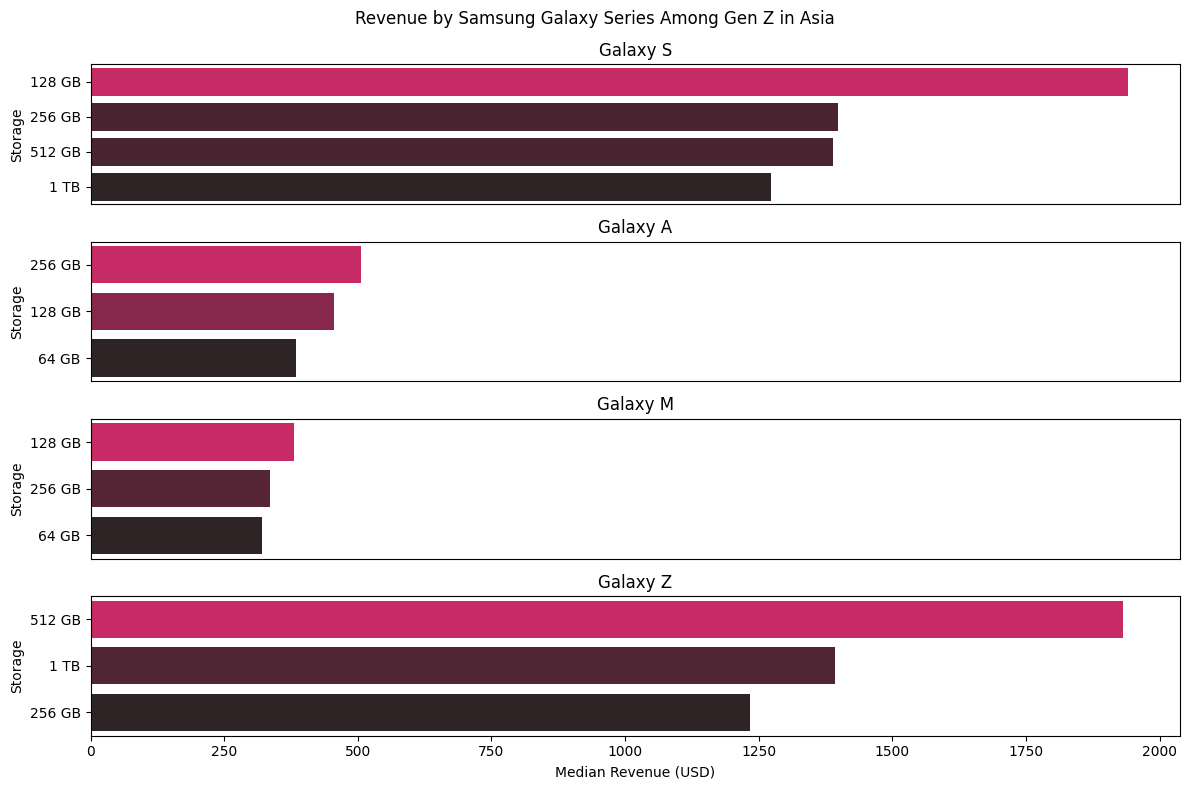

In [ ]:
order = df_product.index.to_list()
df_prefer = df_asia.groupby(["category", "storage"])[["unit_price_usd", "revenue_usd", "units_sold"]].agg(["count", "mean", "median", "sum"])
df_prefer = df_prefer["revenue_usd"].reset_index()


fig, ax = plt.subplots(4, 1, figsize = (12, 8))
plt.suptitle("Revenue by Samsung Galaxy Series Among Gen Z in Asia")
for i, category in enumerate(order):
  df_plot_category = df_prefer[df_prefer["category"] == category]
  sns.barplot(data = df_plot_category.sort_values(by = "median", ascending = False), x = "median", y = "storage", ax = ax[i], hue = "median", palette = "dark:#E0115F", legend = False)
  ax[i].set_title(f"{category}")
  ax[i].set_ylabel("Storage")
  ax[i].set_xlim(0, max(df_prefer["median"]) + 0.05*max(df_plot_category["median"]))
  if i < len(order) - 1:
    ax[i].xaxis.set_visible(False)
  else:
    ax[i].set_xlabel("Median Revenue (USD)")


fig.tight_layout()
plt.show()

Insights
- Samsung Galaxy S and Z generate the highest revenue, indicating that these series either attract a larger number of customers and/or have higher unit prices, making them more suitable for mid-to-high spending consumers.

- Samsung Galaxy A and M generate relatively lower revenue, suggesting that these products are generally priced more affordably for lower-spending consumers, although they contribute less revenue per unit.

- Smartphones with the highest storage capacity tend to generate relatively low revenue, except for the Galaxy A series, suggesting that many Gen Z consumers in Asia may be less interested in high-storage variants due to factors such as higher prices, lower perceived value, or sufficient satisfaction with lower storage capacity.


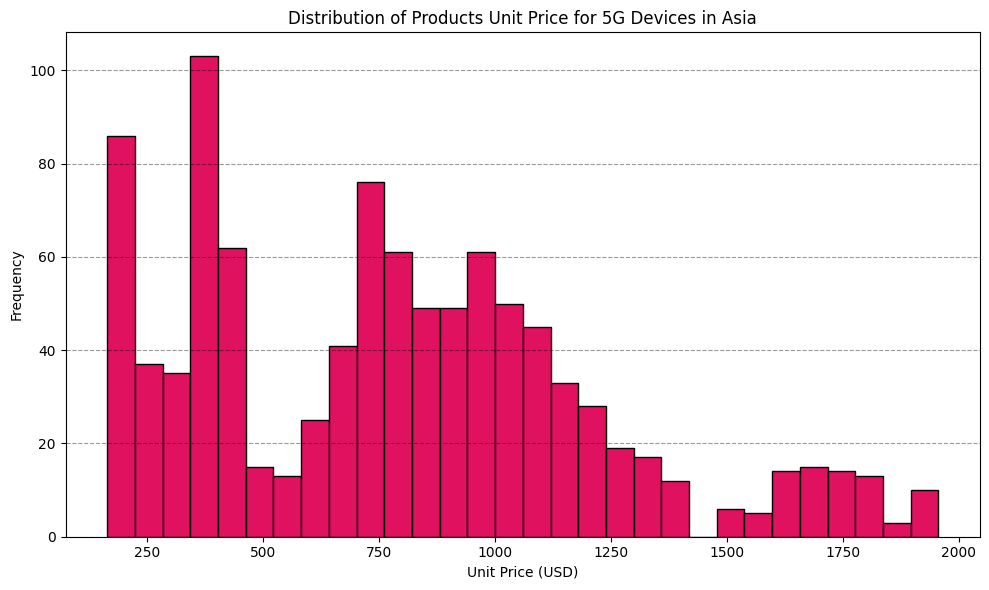

In [ ]:
plt.figure(figsize=(10, 6))
df_just_asia = df[(df["region"] == "Asia") & (df["is_5g"] == "Yes")]
plt.hist(df_just_asia["unit_price_usd"], bins=30, color='#E0115F', edgecolor='black')
plt.title('Distribution of Products Unit Price for 5G Devices in Asia')
plt.xlabel('Unit Price (USD)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.4, color = "black")
plt.tight_layout()
plt.show()

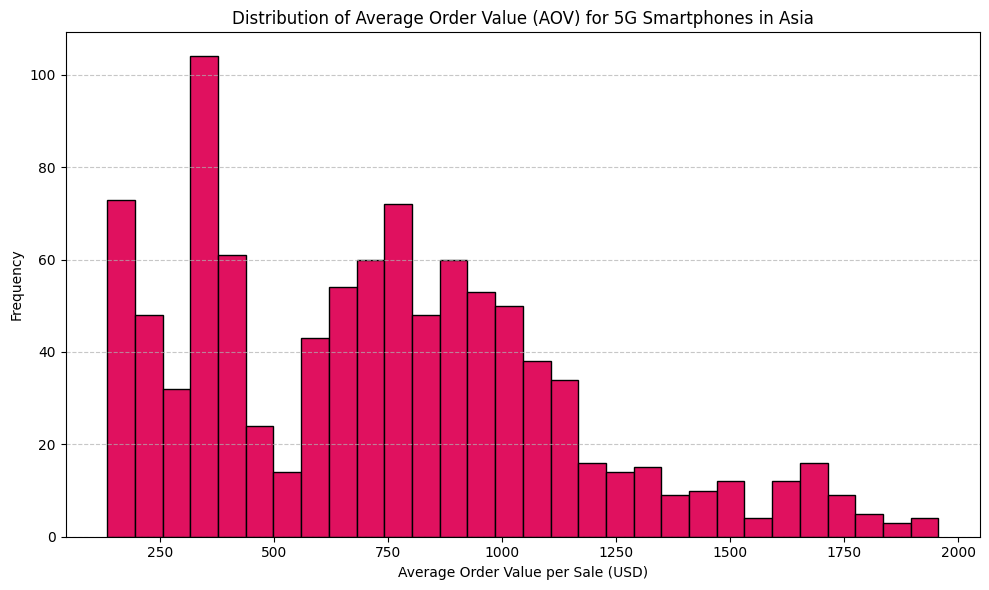

In [ ]:

df_5g_asia = df_just_asia[(df_just_asia["is_5g"] == "Yes")]
df_aov_per_sales = (df_5g_asia["revenue_usd"] / df_5g_asia["units_sold"])

plt.figure(figsize=(10, 6))
plt.hist(df_aov_per_sales, bins=30, color='#E0115F', edgecolor='black')
plt.title('Distribution of Average Order Value (AOV) for 5G Smartphones in Asia')
plt.xlabel('Average Order Value per Sale (USD)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights
- The highest sales and AOV frequencies are observed in the USD 100-450 and USD 650-1,200 price ranges, highlighting strong consumer demand for low and mid-range smartphones in Asia.

- Premium smartphones priced between USD 1,500-1,900 exhibit significantly lower sales and AOV frequencies, indicating that demand for high-end devices is relatively limited.

In [ ]:
df_genz_5g = df[(df["is_5g"] == "Yes") & (df["customer_age_group"] == "18-24")]

df_revenue = df_genz_5g.groupby(["year", "month", "region", "category"])[["revenue_usd", "units_sold"]].agg(["sum", "count"])
df_revenue

revenue_usd       units_sold      
                                              sum count        sum count
year month     region        category                                   
2021 April     Africa        Galaxy A      780.42     1          2     1
               Asia          Galaxy M      567.46     1          2     1
                             Galaxy S     9161.19     6         10     6
                             Galaxy Z      755.39     1          1     1
               Europe        Galaxy S     1885.42     1          2     1
...                                           ...   ...        ...   ...
2024 September Europe        Galaxy S    10123.91     2         11     2
               Middle East   Galaxy A     2900.94     1          7     1
                             Galaxy M      338.41     1          1     1
                             Galaxy Z     1675.74     1          1     1
               South America Galaxy A      208.51     1          1     1

[480 rows x 4 columns]

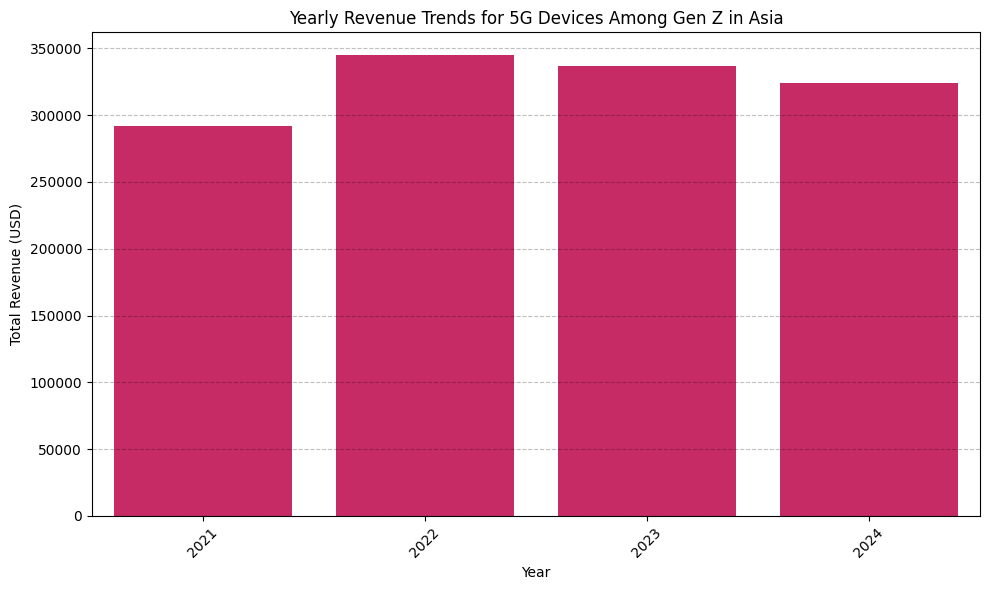

In [ ]:
df_revenue_per_year = df_revenue["revenue_usd"]["sum"].groupby("year").sum().to_frame().rename(columns = {"sum" : "total_revenue"})

plt.figure(figsize=(10, 6))
plt.grid(True, linestyle='--', alpha=0.25, color = "black")
sns.barplot(data = df_revenue_per_year, x = "year", y = "total_revenue", color='#E0115F', alpha=1)
plt.title("Yearly Revenue Trends for 5G Devices Among Gen Z in Asia")
plt.xlabel("Year")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insights
- Revenue showed a strong increase from 2021 to 2022, reaching its peak in 2022, indicating a period of strong product performance and effective marketing.

- Revenue declined slightly after 2022, though the decrease was not substantial, which may indicate several possible factors such as shifting consumer preferences toward competitors, longer smartphone replacement cycles, or less effective product launches and promotional strategies.

In [ ]:
df_aov = (df_revenue["revenue_usd"]["sum"]) / (df_revenue["units_sold"]["count"])
df_aov = df_aov.to_frame().rename(columns={0: 'average_order_value'})
df_aov

average_order_value
year month     region        category                     
2021 April     Africa        Galaxy A              780.420
               Asia          Galaxy M              567.460
                             Galaxy S             1526.865
                             Galaxy Z              755.390
               Europe        Galaxy S             1885.420
...                                                    ...
2024 September Europe        Galaxy S             5061.955
               Middle East   Galaxy A             2900.940
                             Galaxy M              338.410
                             Galaxy Z             1675.740
               South America Galaxy A              208.510

[480 rows x 1 columns]

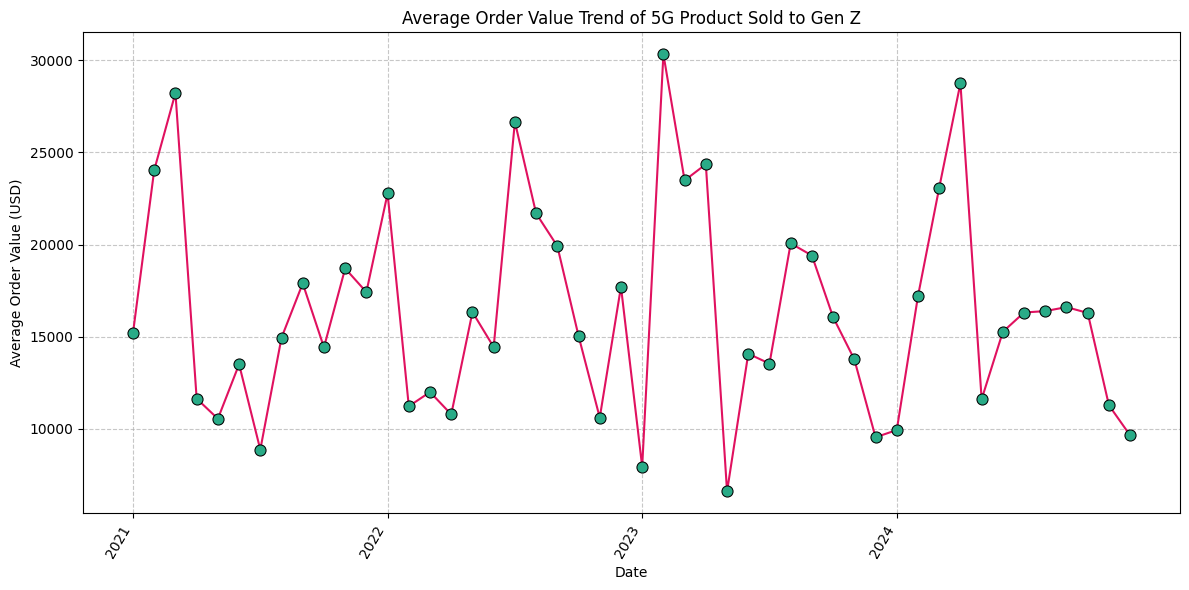

In [ ]:
df_aov_year_month = df_aov.groupby(["year", "month"])["average_order_value"].sum().to_frame().rename(columns = {"sum" : "average_order_value"})
df_aov_year_month = df_aov_year_month.reset_index()
df_aov_year_month["date"] = pd.to_datetime(df_aov_year_month["year"].astype(str) + '-' + df_aov_year_month["month"].astype(str).apply(lambda x: pd.to_datetime(x, format='%B').strftime('%m')) + '-01').dt.strftime('%Y-%m')

plt.figure(figsize=(12, 6))
sns.lineplot(data = df_aov_year_month.sort_values(by = "date", ascending = True), x = "date", y = "average_order_value", marker='o', markersize=8, color='#E0115F', markerfacecolor='#29AB87', markeredgecolor='black')
yearly_ticks = df_aov_year_month[df_aov_year_month['month'] == 'January']
plt.xticks(ticks=yearly_ticks['date'], labels=yearly_ticks['year'], rotation = 60, ha = "right")
plt.title("Average Order Value Trend of 5G Product Sold to Gen Z")
plt.xlabel("Date")
plt.ylabel("Average Order Value (USD)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights
- AOV for 5G smartphones shows a fluctuating trend between 2021 and 2024, indicating periodic spikes in purchasing activity driven by product launches or shifts in consumer interest.

- Significant AOV spikes are commonly observed at the beginning or end of quarters, potentially linked to product release schedules or promotional campaigns.

In [ ]:
df_trend_category = df_asia.groupby(["year", "month", "category"])[["units_sold", "revenue_usd"]].agg(["sum", "mean", "median", "count"])
df_trend_category = df_trend_category.reset_index()
df_trend_category.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_trend_category.columns.values]
df_trend_category["date"] = pd.to_datetime(df_trend_category["year_"].astype("str") + "-" + df_trend_category["month_"].astype("str").apply(lambda x: pd.to_datetime(x, format = "%B").strftime("%m")) + "-01").dt.strftime("%Y-%m")
df_trend_category = df_trend_category.sort_values(by="date")

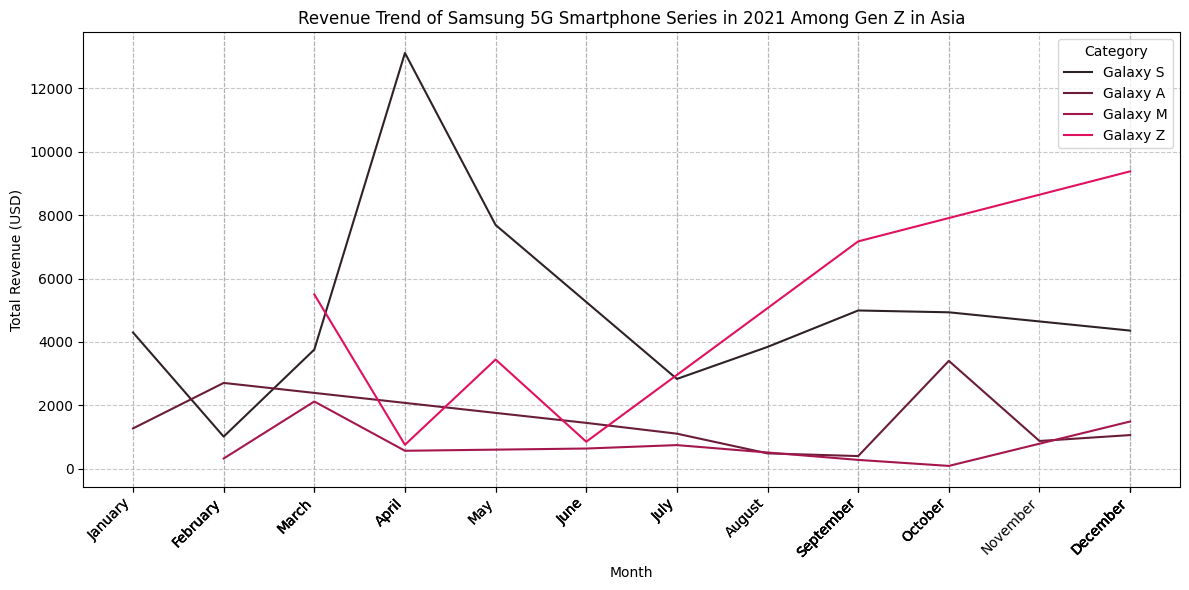

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data = df_trend_category[df_trend_category["year_"] == 2021], x = "date", y = "revenue_usd_sum", hue = "category_", dashes = False, palette = "dark:#E0115F")
plt.title("Revenue Trend of Samsung 5G Smartphone Series in 2021 Among Gen Z in Asia")
plt.xlabel("Month")
plt.ylabel("Total Revenue (USD)")
monthly_ticks = df_trend_category[df_trend_category["year_"] == 2021]
plt.xticks(ticks = monthly_ticks["date"], labels = monthly_ticks["month_"] , rotation = 45, ha = "right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

Insights
- Galaxy S recorded the highest revenue peak in April 2021, highlighting strong market performance at that time because this series offer more than its competitor, leads to shifting preference of Gen Z in Asia.

- Galaxy Z shows stronger revenue performance toward the end of the year, suggesting increasing consumer interest in premium or innovative smartphone designs.

- Galaxy A and M series generate comparatively lower revenue, reflecting their positioning in the lower to mid-range market segment, also competitor offering more than this series at mid-range market.

In [ ]:
df_return = df_just_asia.groupby(["year", "category", "storage", "return_status"])[["units_sold", "revenue_usd"]].agg(["sum", "mean", "count"])
df_return_val = df_return["units_sold"]["count"].groupby(["year", "category", "storage", "return_status"]).agg("sum")
df_return_val = df_return_val.reset_index()
df_return_val = df_return_val[df_return_val["return_status"] == "Returned"]


df_total_order = df_return["units_sold"]["count"].groupby(["year", "category", "storage"]).agg("sum").reset_index()

df_return_rate_per_category = df_return_val.groupby("category")["count"].agg("sum") / df_total_order.groupby("category")["count"].agg("sum")
df_return_rate_per_year = df_return_val.groupby("year")["count"].agg("sum") / df_total_order.groupby("year")["count"].agg("sum")
df_return_rate_per_storage = df_return_val.groupby("storage")["count"].agg("sum") / df_total_order.groupby("storage")["count"].agg("sum")


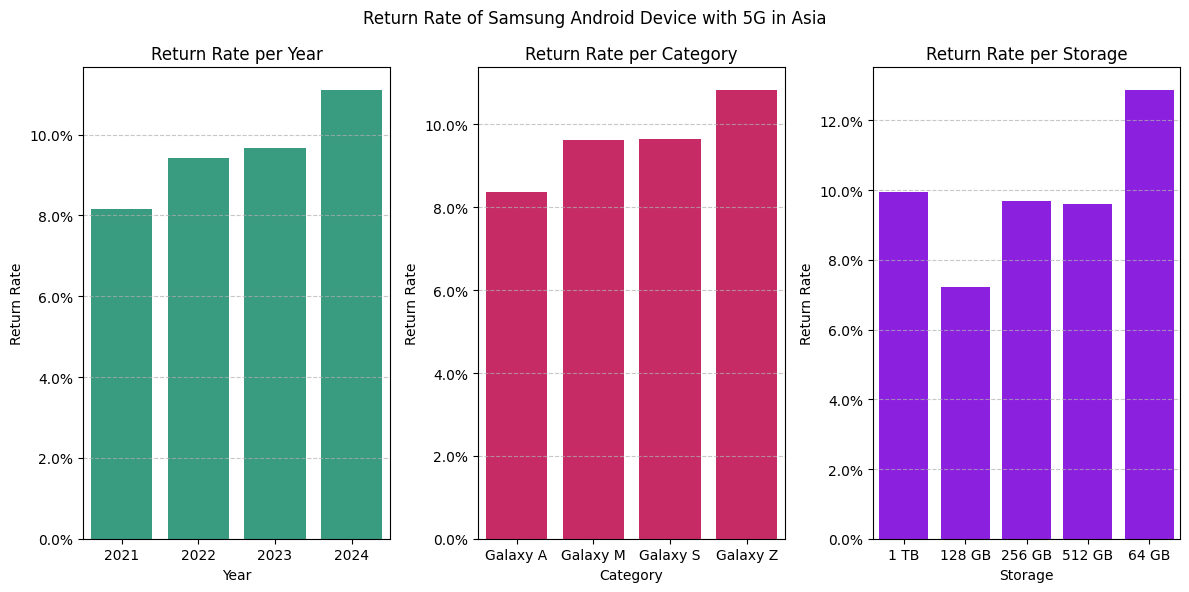

In [ ]:
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(1, 3, figsize = (12, 6))
plt.suptitle("Return Rate of Samsung Android Device with 5G in Asia")
sns.barplot(x = df_return_rate_per_category.index, y = df_return_rate_per_category.values * 100, ax = ax[1], color = "#E0115F")
ax[1].set_title("Return Rate per Category")
ax[1].set_xlabel("Category")
ax[1].set_ylabel("Return Rate")
ax[1].grid(axis = "y", linestyle = "--", alpha = 0.7)
ax[1].yaxis.set_major_formatter(PercentFormatter())

sns.barplot(x = df_return_rate_per_year.index, y = df_return_rate_per_year.values * 100, ax = ax[0], color = "#29AB87")
ax[0].set_title("Return Rate per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Return Rate")
ax[0].grid(axis = "y", linestyle = "--", alpha = 0.7)
ax[0].yaxis.set_major_formatter(PercentFormatter())

sns.barplot(x = df_return_rate_per_storage.index, y = df_return_rate_per_storage.values * 100, ax = ax[2], color = "#8F00FF")
ax[2].set_title("Return Rate per Storage")
ax[2].set_xlabel("Storage")
ax[2].set_ylabel("Return Rate")
ax[2].grid(axis = "y", linestyle = "--", alpha = 0.7)
ax[2].yaxis.set_major_formatter(PercentFormatter())

fig.tight_layout()
plt.show()

Insights
- Samsung's return rates show a consistent increase from 2021 to 2024, which may indicate growing product issues or increasing customer dissatisfaction as Gen Z consumers develop higher expectations for smartphone performance and quality.

- The Samsung Galaxy Z series records the highest return rate among all series, suggesting potential factors such as product issues, unmet customer expectations, or higher return behavior within this segment.

- The Samsung Galaxy A series has the lowest return rate, indicating that these products may better meet customer expectations or experience fewer issues compared to other series.

- Smartphones with 64 GB storage show the highest return rate, which may suggest that many Gen Z consumers require larger storage capacity, leading to higher return rates.

In [ ]:
pip install adjustText

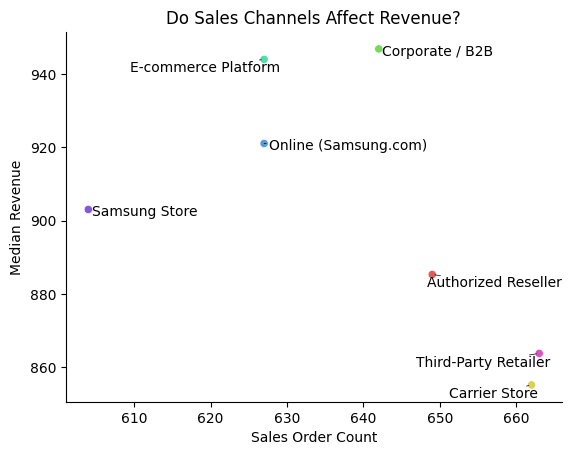

In [ ]:
from adjustText import adjust_text


df_scatter = df.groupby("sales_channel")["revenue_usd"].agg(["median", "count"])
sns.scatterplot(data = df_scatter, x = "count", y = "median", hue = "sales_channel", palette = "hls", legend = False)
sns.despine()

texts = []
for i, txt in enumerate(df_scatter.index):
  texts.append(plt.text(df_scatter["count"].iloc[i], df_scatter["median"].iloc[i], txt, ha = "center", va = "top"))

adjust_text(texts, arrowprops = dict(arrowstyle = "-", color = "black", lw = 0.5))


plt.title("Do Sales Channels Affect Revenue?")
plt.xlabel("Sales Order Count")
plt.ylabel("Median Revenue")
plt.show()


Insights
- Online channels appear to be an efficient revenue driver, generating strong revenue with relatively fewer transactions.

- Corporate/B2B sales represent a key revenue contributor due to high-volume purchasing behavior.

- Samsung stores may rely on premium product sales to generate high revenue despite lower transaction volumes.

- Other offline stores record high order volumes but relatively low revenue, suggesting lower-priced products, smaller average order values per transaction, or or heavier promotional activities.

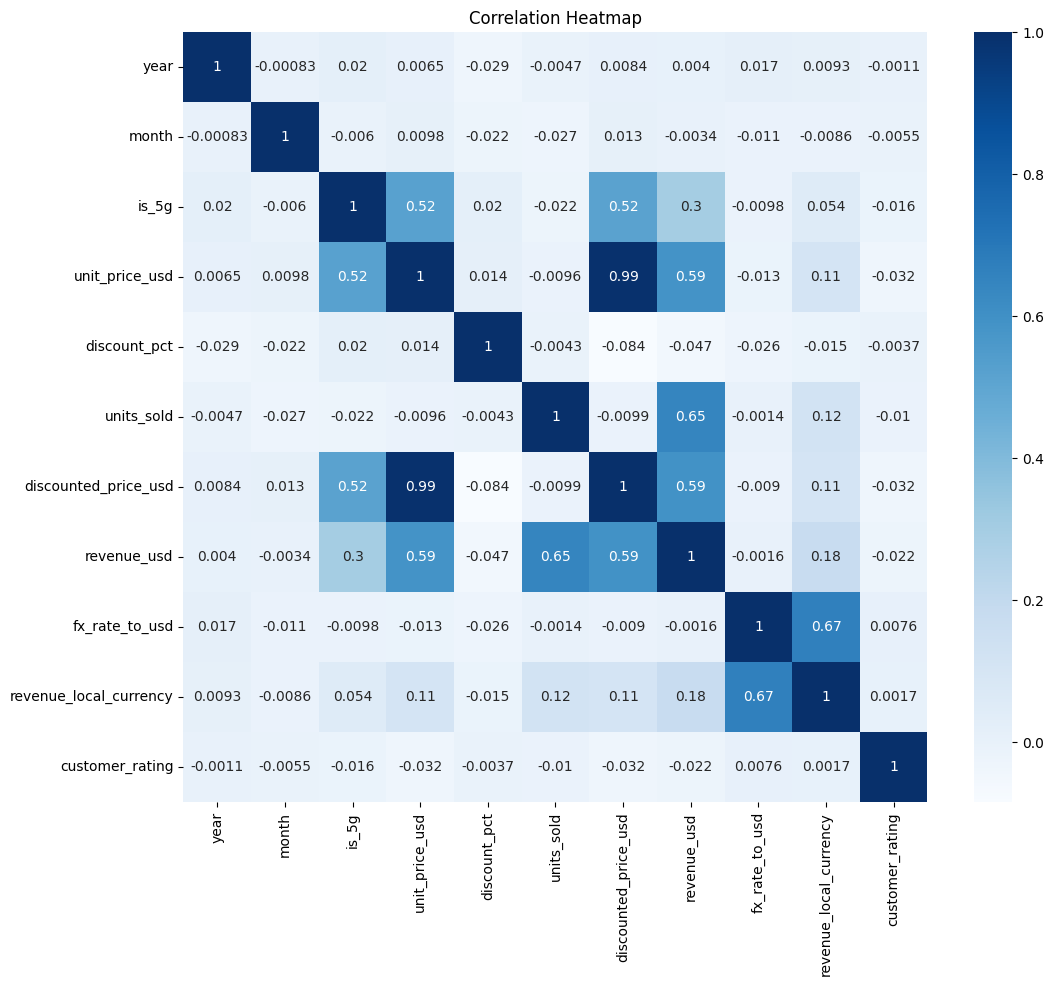

In [ ]:
df_heat = df.copy()
df_heat["is_5g"] = df_heat["is_5g"].str.replace("No", "0").str.replace("Yes", "1").astype(int)
df_heat["month"] = pd.to_datetime(df_heat["month"], format='%B').dt.month.astype(int)

num_val = [col for col in df_heat.columns if (df_heat[col].dtype == "int64") | (df_heat[col].dtype == "float64") ]
plt.figure(figsize=(12, 10))
sns.heatmap(df_heat[num_val].corr(), annot = True, cmap = "Blues")
plt.title("Correlation Heatmap")
plt.show()

# Hypothesis Testing

## 1. Do Higher Discounts Lead to Higher Units Sold for 5G Products in Asia?

In [ ]:
# Mean Difference of Two Sample Test
#--------------------------------------
# Filter
df_just_asia["discount_group"] = df_just_asia["discount_pct"].apply(lambda x : "High Discount" if x >= 0.10 else "Low Discount")
#Group
low_discount = df_just_asia[df_just_asia["discount_group"] == "Low Discount"]["units_sold"]
high_discount = df_just_asia[df_just_asia["discount_group"] == "High Discount"]["units_sold"]

# Hypothesis Null H_0 : mean(low_discount) = mean(high_discount)
# Hypothesis Alternative H_1 : mean(low_discount) != mean(high_discount)

# Type I Error (alpha)
# Level of Significance (probability: alpha)   [alpha smaller -> hypothesis testing more meaningful]
alpha = 0.05 # (usually alpha = 0.05 for Confidence Interval 95% and alpha = 0.01 for Confidence Interval 99%)






/tmp/ipykernel_327/364270684.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_just_asia["discount_group"] = df_just_asia["discount_pct"].apply(lambda x : "High Discount" if x >= 0.10 else "Low Discount")


In [ ]:
from scipy.stats import ttest_ind, t
# Statistical Test
t_statistic, p_value = ttest_ind(low_discount, high_discount)
print(f"T-Statistic : {t_statistic}")
print(f"P-Value : {p_value}")

T-Statistic : -0.4858528028330892
P-Value : 0.6271785064597991


In [ ]:
if p_value < alpha:
  print(f"Reject H0: There's significant difference between Low Discount and High Discount Group")
else:
  print(f"Can't Reject H0: There's no significant difference between Low Discount and High Discount Group")

Can't Reject H0: There's no significant difference between Low Discount and High Discount Group


In [ ]:
# Confidence Interval
#----------------------
mean_low = low_discount.mean()
mean_high = high_discount.mean()

std_low = low_discount.std()
std_high = high_discount.std()

n_low = len(low_discount)
n_high = len(high_discount)

mean_diff = mean_high - mean_low

# Standard Error
se = np.sqrt((std_low**2 / n_low) + (std_high**2 / n_high))
print(f"Standard Error : {se}")
# Degree of Freedom
dfree = n_low + n_high - 2
print(f"Degree of Freedom : {dfree}")

# t-value
t_value = t.ppf(1 - alpha/2, dfree)
print(f"t-value : {t_value}")

# Margin of Error
margin_error = t_value * se
print(f"Margin of Error : {margin_error}")

# Confidence Interval
ci_low = mean_diff - margin_error
ci_high = mean_diff + margin_error
print(f"Mean Difference: {mean_diff}")
print(f"{int((1-alpha)*100)}% Confidence Interval : [{ci_low}, {ci_high}]")

Standard Error : 0.12813074432205848
Degree of Freedom : 995
t-value : 1.962351030264214
Margin of Error : 0.25143749812891203
Mean Difference: 0.06305282424552017
95% Confidence Interval : [-0.18838467388339186, 0.3144903223744322]


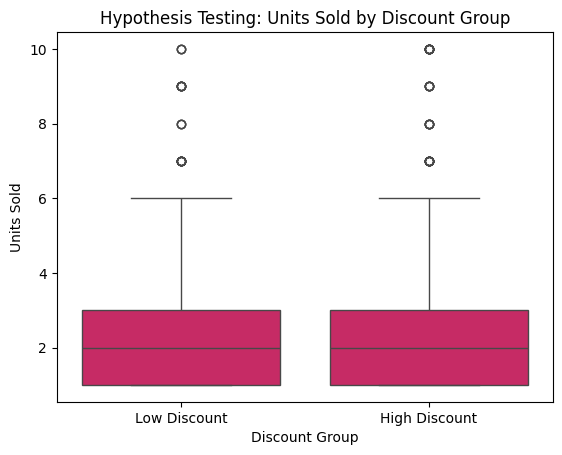

In [ ]:
# Visualization
sns.boxplot(data = df_just_asia, x = "discount_group", y = "units_sold", color = "#E0115F")
plt.title("Hypothesis Testing: Units Sold by Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Units Sold")
plt.show()

In [ ]:
# Effect Size
pooled_std = np.sqrt(((n_low - 1) * std_low**2 + (n_high - 1) * std_high**2) / (n_low + n_high - 2))
#Cohen's d Effect Size (used for mean difference of two sample test)
effect_size = (mean_high - mean_low) / pooled_std

print(f"Effect Size : {effect_size}")

Effect Size : 0.03165068052598687


### Insights
- There's no statistically significant difference between the low-discount and high-discount groups, suggesting that higher discounts do not appear to be associated with increased units sold for 5G products in Asia.
- The 95% confidence interval for the mean difference ranged from -0.19 to 0.32, which includes zero, further suggesting that there is insufficient evidence to conclude that higher discounts lead to higher sales.
- The effect size was extremely small (Cohen's d = 0.03), suggesting that the practical impact of higher discounts on unit sales is negligible.

## 2. Does Sales Channel Type Affect Revenue?

In [ ]:
# Mean Difference of Two Sample Test
online_channels = ["E-commerce Platform", "Online (Samsung.com)"]
# Level of Significance
alpha = 0.05
# Groupping
df["channel_type"] = df["sales_channel"].apply(lambda x : "Online" if x in online_channels else "Offline")

df_online = df[df["channel_type"] == "Online"]["revenue_usd"]
df_offline = df[df["channel_type"] == "Offline"]["revenue_usd"]

pd.crosstab(df["region"], df["channel_type"])

channel_type,Offline,Online
region,,
Africa,300,120
Asia,908,361
Europe,1142,431
Europe/Asia,125,51
Middle East,120,52
North America,198,76
Oceania,122,57
South America,305,106


In [ ]:
# Statistical Test
t_statistic, p_value = ttest_ind(df_online, df_offline)
print(f"T-Statistic : {t_statistic}")
print(f"P-Value : {p_value}")

T-Statistic : 0.8611468053418565
P-Value : 0.38920336173296555


In [ ]:
# Confidence Interval
#----------------------
mean_online = df_online.mean()
mean_offline = df_offline.mean()

std_online = df_online.std()
std_offline = df_offline.std()

n_online = len(df_online)
n_offline = len(df_offline)

mean_diff = mean_offline - mean_online

# Standard Error
se = np.sqrt((std_online**2 / n_online) + (std_offline**2 / n_offline))
print(f"Standard Error : {se}")
# Degree of Freedom
dfree = n_online + n_offline - 2
print(f"Degree of Freedom : {dfree}")

# t-value
t_value = t.ppf(1 - alpha/2, dfree)
print(f"t-value : {t_value}")

# Margin of Error
margin_error = t_value * se
print(f"Margin of Error : {margin_error}")

# Confidence Interval
ci_online = mean_diff - margin_error
ci_offline = mean_diff + margin_error
print(f"Mean Difference: {mean_diff}")
print(f"{int((1-alpha)*100)}% Confidence Interval : [{ci_online}, {ci_offline}]")

Standard Error : 59.923868118566574
Degree of Freedom : 4472
t-value : 1.960494597801946
Margin of Error : 117.48041972584602
Mean Difference: -50.8500576490635
95% Confidence Interval : [-168.33047737490952, 66.63036207678252]


In [ ]:
# Effect Size
pooled_std = np.sqrt(((n_online - 1) * std_online**2 + (n_offline - 1) * std_offline**2) / (n_online + n_offline - 2))
#Cohen's d Effect Size (used for mean difference of two sample test)
effect_size = (mean_offline - mean_online) / pooled_std

print(f"Effect Size : {effect_size}")

Effect Size : -0.028664771263266674


In [ ]:
df_sales_channel_type = df.groupby(["region", "channel_type"])[["revenue_usd", "units_sold", "customer_rating"]].agg(["mean", "count", "sum"])

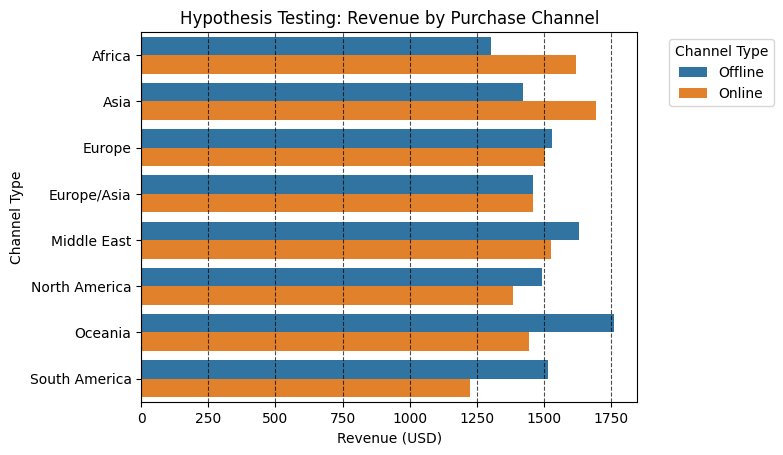

In [ ]:
# Visualization
df_plot = df_sales_channel_type["revenue_usd"].reset_index()
sns.barplot(data = df_plot, y = "region", x = "mean", hue = "channel_type")
plt.title("Hypothesis Testing: Revenue by Purchase Channel")
plt.xlabel("Revenue (USD)")
plt.ylabel("Channel Type")
plt.legend(title = "Channel Type", bbox_to_anchor = (1.05, 1), loc = 2)
plt.grid(axis = "x", linestyle = "--", alpha = 0.7, color = "black")
plt.show()

In [ ]:
region = df["region"].unique()
for i in range (len(region)):
  df_region = df[df["region"] == region[i]]
  df_online = df_region[df_region["channel_type"] == "Online"]["revenue_usd"]
  df_offline = df_region[df_region["channel_type"] == "Offline"]["revenue_usd"]
  print("")
  print(f"Hypothesis Testing of Revenue based on Sales Channel Type in {region[i]} Region")
  print("----------------------------------------------------------------------------------")
  # Statistical Test
  t_statistic, p_value = ttest_ind(df_online, df_offline)
  print("-----------------------------------")
  print(f"T-Statistic : {t_statistic}")
  print(f"P-Value : {p_value}")
  print("-----------------------------------")
  # Confidence Interval
  #----------------------
  mean_online = df_online.mean()
  mean_offline = df_offline.mean()

  std_online = df_online.std()
  std_offline = df_offline.std()

  n_online = len(df_online)
  n_offline = len(df_offline)

  mean_diff = mean_offline - mean_online

  # Standard Error
  se = np.sqrt((std_online**2 / n_online) + (std_offline**2 / n_offline))
  print(f"Standard Error : {se}")
  # Degree of Freedom
  dfree = n_online + n_offline - 2
  print(f"Degree of Freedom : {dfree}")

  # t-value
  t_value = t.ppf(1 - alpha/2, dfree)
  print(f"t-value : {t_value}")

  # Margin of Error
  margin_error = t_value * se
  print(f"Margin of Error : {margin_error}")

  # Confidence Interval
  ci_online = mean_diff - margin_error
  ci_offline = mean_diff + margin_error
  print("--------------------------------------------------------------------------")
  print(f"Mean Difference: {mean_diff}")
  print(f"{int((1-alpha)*100)}% Confidence Interval : [{ci_online}, {ci_offline}]")
  print("--------------------------------------------------------------------------")
  # Effect Size
  pooled_std = np.sqrt(((n_online - 1) * std_online**2 + (n_offline - 1) * std_offline**2) / (n_online + n_offline - 2))
  #Cohen's d Effect Size (used for mean difference of two sample test)
  effect_size = (mean_offline - mean_online) / pooled_std
  print("-------------------------------")
  print(f"Effect Size : {effect_size}")
  print("-------------------------------")
  print("")
  print("")


Hypothesis Testing of Revenue based on Sales Channel Type in South America Region
----------------------------------------------------------------------------------
-----------------------------------
T-Statistic : -1.4883558011524023
P-Value : 0.1374276854834592
-----------------------------------
Standard Error : 151.70488211927565
Degree of Freedom : 409
t-value : 1.9657810689090571
Margin of Error : 298.2185853311522
--------------------------------------------------------------------------
Mean Difference: 288.80449458707085
95% Confidence Interval : [-9.414090744081363, 587.0230799182231]
--------------------------------------------------------------------------
-------------------------------
Effect Size : 0.16781269930646048
-------------------------------



Hypothesis Testing of Revenue based on Sales Channel Type in Oceania Region
----------------------------------------------------------------------------------
-----------------------------------
T-Statistic : -1.014716886

### Insights for Hypothesis 2: Does Sales Channel Type Affect Revenue?

- Overall, there's no statistically significant difference in revenue between online and offline sale channels globally (p-value = 0.389 > 0.05).
- The 95% confidence interval for the mean difference (Offline - Online) is [-168.33, 66.63], which includes zero, indicating no significant difference.
- The effect size is very small (Cohen's d = -0.028), suggesting a negligible practical impact of sales channel type on revenue at a global level.


However, when looking at the Asian region:
- In contrast, a statistically significant difference in revenue is observed between sales channels in the Asian region (p-value = 0.0127 < 0.05).
- The mean difference in revenue (Offline - Online) for Asia is -271.67 USD. The 95% confidence interval is [-502.82, -40.51], which does not include zero. This suggests that, in the Asian market, online sales channels tend to generate significantly higher revenue per sale compared to offline channels.
- However, the effect size is small (Cohen’s d = -0.155), suggesting that while the difference is statistically significant, the practical impact is relatively modest.

While for the remaining regions:
- The p-values are greater than 0.05 and the confidence intervals include zero, suggesting that there is no statistically significant difference in revenue between online and offline sales channels in those markets.


# Machine Learning

## Regression

### Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as rsme

# copy df
df_reg = df.copy()

# change categorical to numerical
df_reg["is_5g"] = df_reg["is_5g"].str.replace("No", "0").str.replace("Yes", "1").astype(int)
df_reg["storage"] = df_reg["storage"].str.replace("64 GB", "1").str.replace("128 GB", "2").str.replace("256 GB", "3").str.replace("512 GB", "4").str.replace("1 TB", "5").astype(int)
df_reg["channel_type"] = df_reg["sales_channel"].apply(lambda x : "Online" if x in online_channels else "Offline")
df_reg["channel_type"] = df_reg["channel_type"].str.replace("Online", "1").str.replace("Offline", "0").astype(int)
df_reg["customer_age_group"] = df_reg["customer_age_group"].str.replace("18-24", "1").str.replace("25-34", "2").str.replace("35-44", "3").str.replace("45-54", "4").str.replace("55+", "5").astype(int)
df_reg["customer_rating"] = df_reg["customer_rating"].astype(int)
df_reg = pd.get_dummies(df_reg, columns = ["previous_device_os", "category"])
df_reg.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'storage', 'color', 'is_5g', 'unit_price_usd',
       'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd',
       'currency', 'fx_rate_to_usd', 'revenue_local_currency', 'sales_channel',
       'payment_method', 'customer_segment', 'customer_age_group',
       'customer_rating', 'return_status', 'channel_type',
       'previous_device_os_Android (Other)',
       'previous_device_os_Android (Samsung)',
       'previous_device_os_Feature Phone', 'previous_device_os_New User',
       'previous_device_os_iOS', 'category_Galaxy A', 'category_Galaxy M',
       'category_Galaxy S', 'category_Galaxy Z'],
      dtype='object')

In [ ]:
# features
X = df_reg[["is_5g", "storage", "unit_price_usd", "discount_pct", "channel_type", "customer_age_group", 'previous_device_os_Android (Other)',
       'previous_device_os_Android (Samsung)',
       'previous_device_os_Feature Phone', 'previous_device_os_New User',
       'previous_device_os_iOS', 'category_Galaxy A', 'category_Galaxy M',
       'category_Galaxy S', 'category_Galaxy Z']]

# target
y = df_reg["revenue_usd"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
model = LinearRegression()

# training
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

# evaluation
mae = mean_absolute_error(y_test, y_pred)
loss = rsme(y_test, y_pred)

# determination
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", loss)
print("R-squared:", r2)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Variance: {}".format(model.score(X_test, y_test)))

Mean Absolute Error: 882.0481459512911
Root Mean Squared Error: 2057844.0452159615
R-squared: 0.32711639808570003
Coefficients: [-35.58218147  26.60131595   2.35458495 -15.67988634  20.18616035
   6.70664786 -63.00383979 -30.25965901  74.1090461  102.17999505
 -83.02554235  47.29659542  43.66716785 -76.00874258 -14.95502069]
Intercept: -37.51878047788978
Variance: 0.32711639808570003


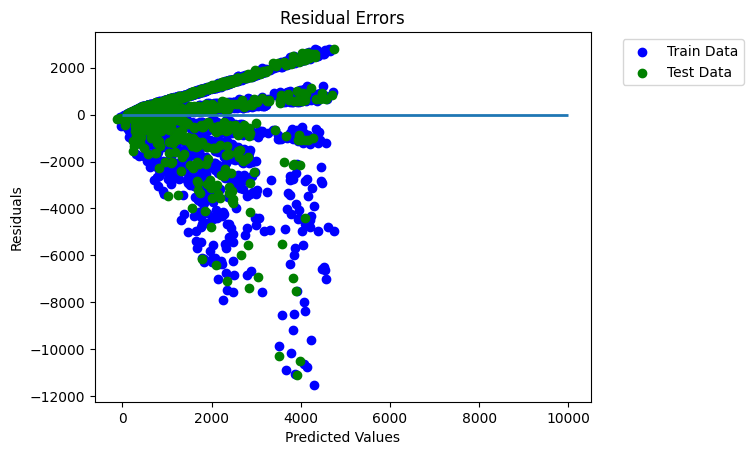

In [ ]:
# Plotting Residual Errors (for multiple linear regression)

# Plotting Residual Errors in Training Data
plt.scatter(model.predict(X_train), model.predict(X_train) - y_train, color = "blue", label = "Train Data")

# Plotting Residual Errors in Test Data
plt.scatter(model.predict(X_test), model.predict(X_test) - y_test, color = "green", label = "Test Data")

# Plotting Line for Zero Residual Error
plt.hlines(y = 0, xmin = 0, xmax = 10000, linewidth = 2)

plt.legend(bbox_to_anchor = (1.05, 1), loc = 2)
plt.title("Residual Errors")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

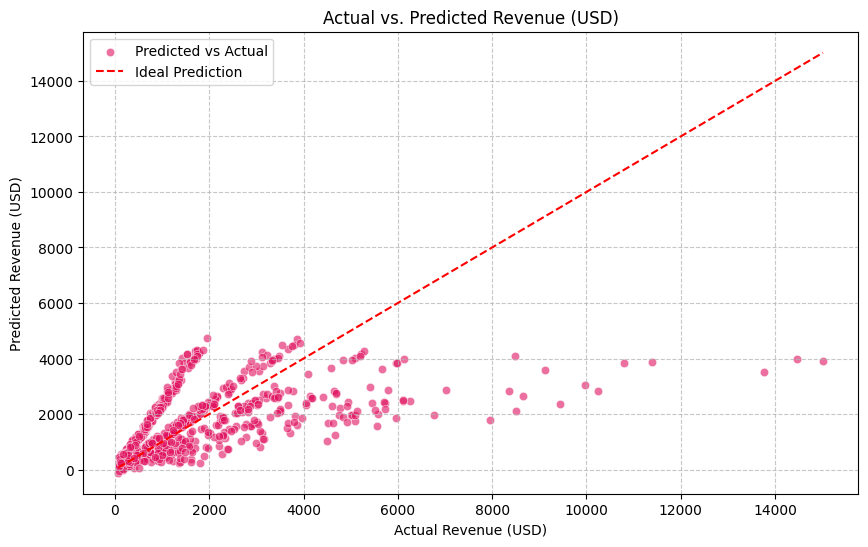

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='#E0115F', alpha=0.6, label='Predicted vs Actual')
sns.lineplot(x=y_test, y=y_test, color='red', linestyle='--', label='Ideal Prediction')
plt.title('Actual vs. Predicted Revenue (USD)')
plt.xlabel('Actual Revenue (USD)')
plt.ylabel('Predicted Revenue (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Insights
- The model shows strong performance in low-to-mid revenue ranges (≤ USD 6,500), where predictions closely follow the ideal line.

- However, it systematically underestimates high-revenue observations (> USD 6,500), indicating poor generalization for high-value transactions.

- The prediction ceiling at around USD 4,500 suggests model constraints, likely due to limited feature representation.

- Visible clustering patterns in the scatter plot indicate that predictions are driven by discrete feature groupings, rather than continuous variation.

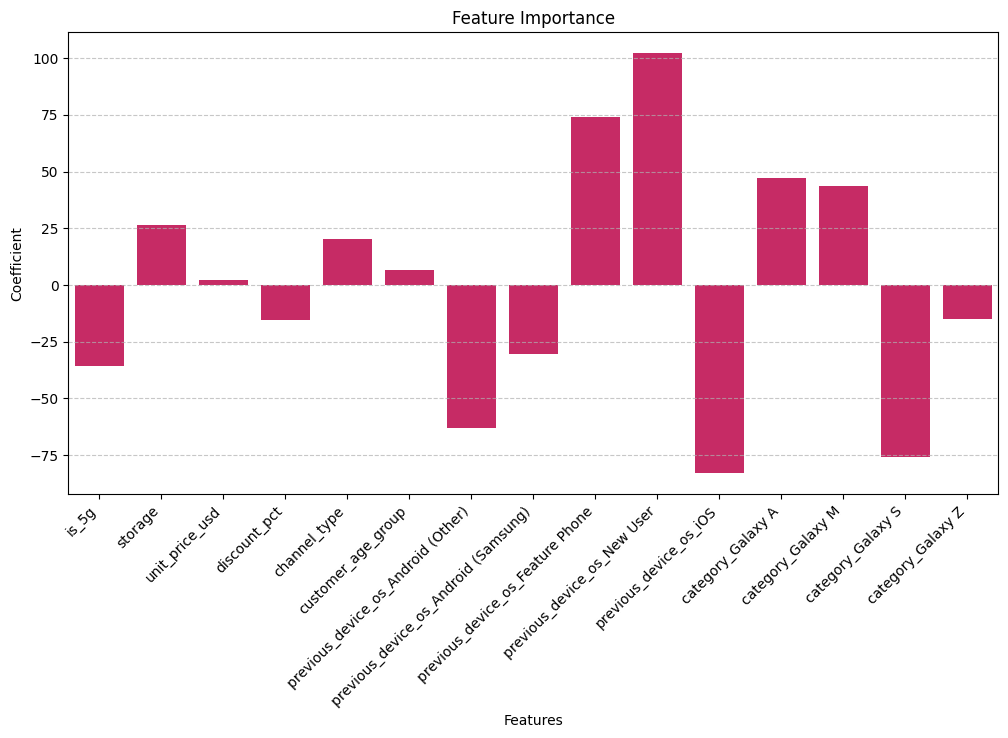

In [ ]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
plt.figure(figsize=(12, 6))
sns.barplot(x=coeff_df.index, y='Coefficient', data=coeff_df, color='#E0115F')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Coefficient')
plt.grid(True, linestyle='--', alpha=0.7, axis = "y")
plt.xticks(rotation = 45, ha = "right")
plt.show()

#### Insights
- Positively correlated features (e.g., storage capacity, sales channel, and customer demographics) play a key role in driving revenue, highlighting potential areas for strategic focus.

- Negatively correlated features may indicate underperforming aspects of the product or strategy, which should be reviewed and optimized to enhance overall revenue performance.

## Classification

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


df_logreg = df.copy()
df_logreg["returned"] = df_logreg["return_status"].apply(lambda x: 1 if x in ["Returned", "Exchanged"] else 0)
df_logreg["is_5g"] = df_logreg["is_5g"].str.replace("No", "0").str.replace("Yes", "1").astype(int)
df_logreg["storage"] = df_logreg["storage"].str.replace("64 GB", "1").str.replace("128 GB", "2").str.replace("256 GB", "3").str.replace("512 GB", "4").str.replace("1 TB", "5").astype(int)
df_logreg["channel_type"] = df_logreg["sales_channel"].apply(lambda x : 1 if x in online_channels else 0) # 1 = Online, 0 = Offline
df_logreg["customer_age_group"] = df_logreg["customer_age_group"].str.replace("18-24", "1").str.replace("25-34", "2").str.replace("35-44", "3").str.replace("45-54", "4").str.replace("55+", "5").astype(int)
df_logreg["customer_rating"] = df_logreg["customer_rating"].astype(int)
df_logreg = pd.get_dummies(df_logreg, columns = ["previous_device_os", "category"])
df_logreg.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'storage', 'color', 'is_5g', 'unit_price_usd',
       'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd',
       'currency', 'fx_rate_to_usd', 'revenue_local_currency', 'sales_channel',
       'payment_method', 'customer_segment', 'customer_age_group',
       'customer_rating', 'return_status', 'channel_type', 'returned',
       'previous_device_os_Android (Other)',
       'previous_device_os_Android (Samsung)',
       'previous_device_os_Feature Phone', 'previous_device_os_New User',
       'previous_device_os_iOS', 'category_Galaxy A', 'category_Galaxy M',
       'category_Galaxy S', 'category_Galaxy Z'],
      dtype='object')

In [ ]:
features = ['is_5g', 'storage', 'customer_rating', 'channel_type', 'unit_price_usd', 'discount_pct',
            'previous_device_os_Android (Other)','previous_device_os_Android (Samsung)',
            'previous_device_os_Feature Phone', 'previous_device_os_New User',
            'previous_device_os_iOS', 'category_Galaxy A', 'category_Galaxy M',
       'category_Galaxy S', 'category_Galaxy Z', 'customer_age_group', 'customer_rating']

X = df_logreg[features]
y = df_logreg["returned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(class_weight = "balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("------------------------------------------")
print("Confusion Matrix:\n", conf_matrix)
print("------------------------------------------")
print("Classification Report:\n", class_report)

Accuracy: 0.5441340782122905
------------------------------------------
Confusion Matrix:
 [[421 336]
 [ 72  66]]
------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.56      0.67       757
           1       0.16      0.48      0.24       138

    accuracy                           0.54       895
   macro avg       0.51      0.52      0.46       895
weighted avg       0.75      0.54      0.61       895



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


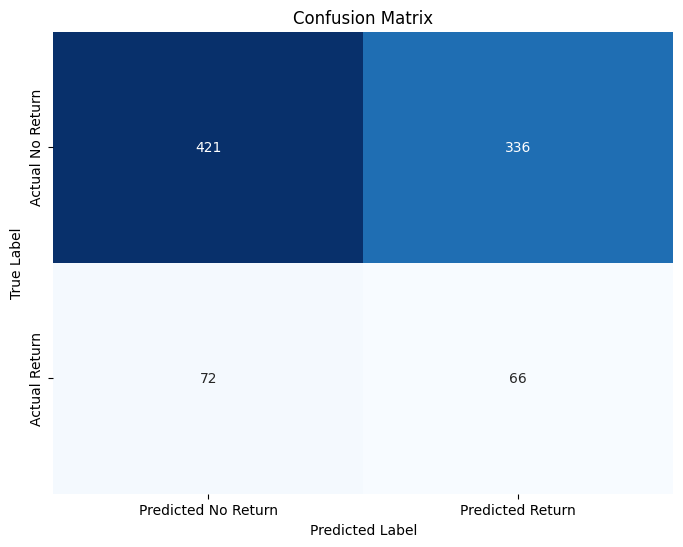

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Return', 'Predicted Return'], yticklabels=['Actual No Return', 'Actual Return'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Insights
- The model is able to identify 66 return cases, showing that it has learned patterns related to product returns.

- However, it misses 72 actual return cases, meaning that nearly half of the returns are not detected. This indicates that the model's recall for return prediction is still limited.

- A major issue is the high number of false positives (336 cases), where the model predicts a return but the product was not actually returned.

- As a result, the precision for return prediction is very low (~16%), meaning most predicted returns are incorrect.

/tmp/ipykernel_327/577556506.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='viridis')


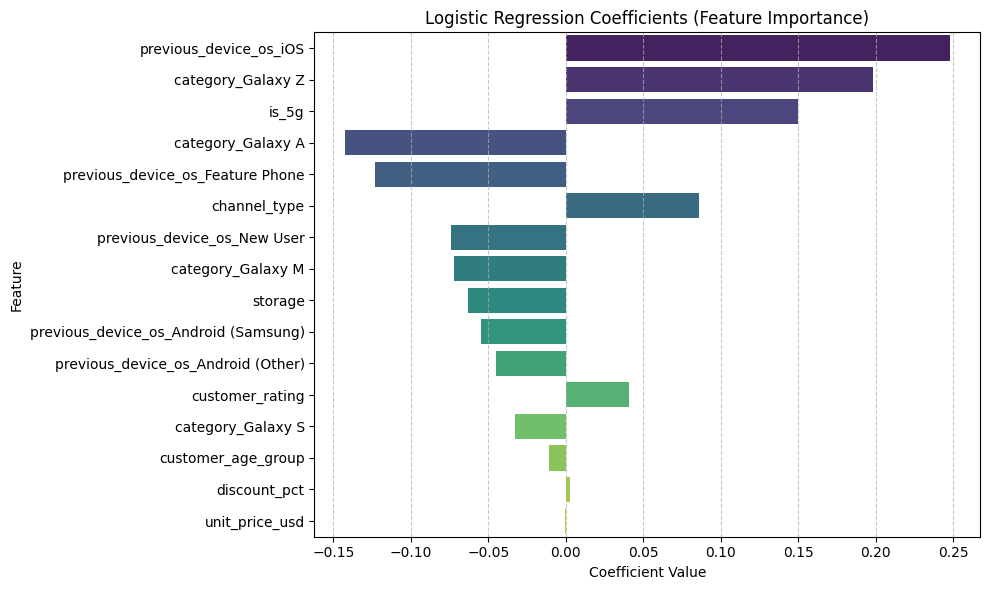

In [ ]:
# Visualize Coefficients (Feature Importance)
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefficients['Absolute_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='viridis')
plt.title('Logistic Regression Coefficients (Feature Importance)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights
- Higher return probability is associated with Galaxy Z purchases, 5G devices, online channels, and prior iOS users, indicating potential expectation gaps or product experience issues.

- Lower return probability is linked to budget devices with higher storage and non-iOS users, suggesting stronger product-market fit and user satisfaction within this segment.